## Hipótesis previas

Antes de explorar los datos, planteamos las siguientes hipótesis sobre qué variables pueden influir en si una persona gana más o menos de 50.000 u.m.:

1. **Hipótesis de Género**: Los hombres tendrán una mayor probabilidad de superar los 50.000 u.m. debido a las brechas salariales históricas por género.

2. **Hipótesis de Educación**: Las personas con mayor nivel educativo tendrán salarios más altos. Títulos universitarios o de posgrado estarán asociados a ingresos >50K.

3. **Hipótesis de Edad**: Las personas de mayor edad tendrán más experiencia laboral acumulada y, por tanto, mayores ingresos, hasta llegar a un punto de inflexión (jubilación).

4. **Hipótesis de Estado Civil**: Las personas casadas (especialmente Married-civ-spouse) tendrán mayores ingresos, posiblemente por el efecto de selección (parejas con mayor estabilidad económica).

5. **Hipótesis de Ocupación**: Las ocupaciones ejecutivas y profesionales especializadas (Exec-managerial, Prof-specialty) estarán más asociadas a ingresos altos.

6. **Hipótesis de Horas trabajadas**: Las personas que trabajan más horas semanales tendrán más probabilidad de superar los 50.000 u.m.

7. **Hipótesis de Capital**: Las personas con ganancias de capital (capital-gain > 0) tendrán ingresos más altos, ya que estas ganancias suelen estar asociadas a inversiones y patrimonio.

8. **Hipótesis de Tipo de empleador**: Los trabajadores del gobierno federal y los autónomos con empresa (Self-emp-inc) tendrán salarios más altos en comparación con los empleados privados.

9. **Hipótesis de País de origen**: La mayoría de registros serán de Estados Unidos. Podría existir diferencia entre nativos y no nativos.

10. **Hipótesis de Interacciones**:
    - **Género y Educación**: Las mujeres con educación universitaria reducirán la brecha salarial respecto a los hombres.
    - **Edad y Ocupación**: Las personas mayores en ocupaciones ejecutivas concentrarán la mayoría de los ingresos altos.
    - **Estado Civil y Género**: Los hombres casados serán el grupo con mayor proporción de ingresos >50K.

# Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, f_oneway
import warnings
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df_raw = pd.read_csv('../data/income_data.csv')

In [3]:
df_raw.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df_raw.shape

(48842, 15)

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [6]:
numeric_cols = [col for col in df_raw.columns if df_raw[col].dtype in ['int64', 'float64']]
str_cols = [col for col in df_raw.columns if df_raw[col].dtype == 'object']

print(f'variables numericas {numeric_cols}')
print(f'-----------------------------------------------')
print(f'variables categoricas {str_cols}')

variables numericas ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
-----------------------------------------------
variables categoricas ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


Vemos como se distribuye la variable objetivo

In [7]:
df_raw['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

## Análisis Univariado

###  Columnas numéricas

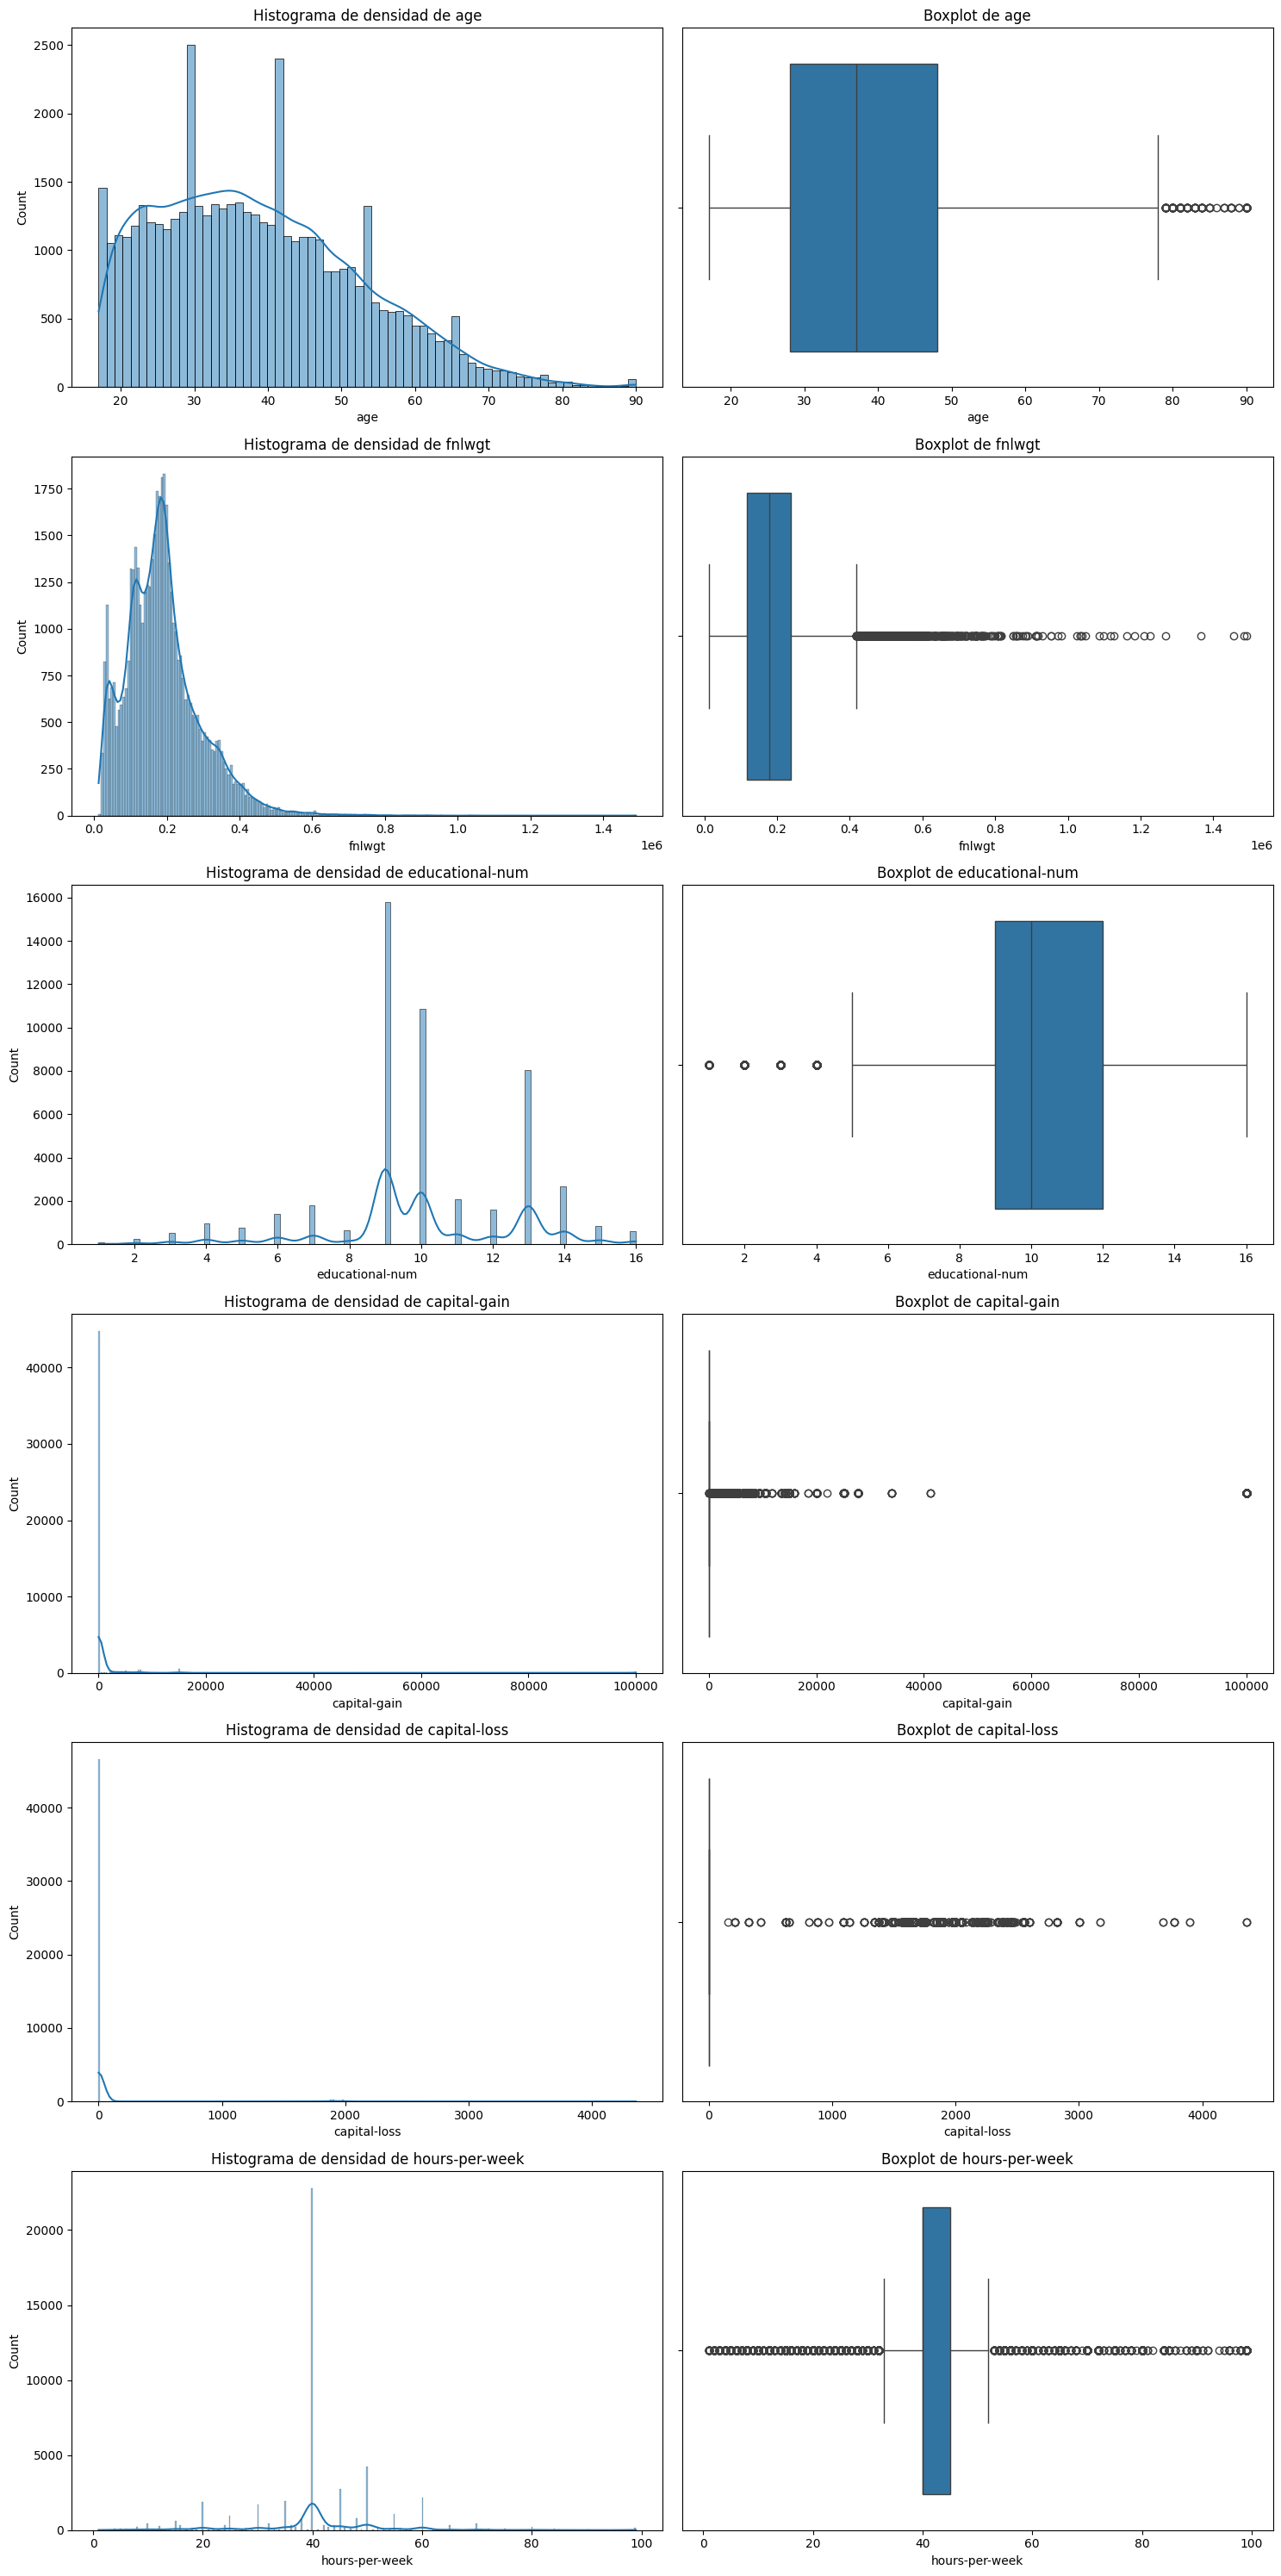

In [8]:
fig, axes = plt.subplots(nrows=len(df_raw.select_dtypes(include=[np.number]).columns), ncols=2, figsize=(15, 5 * len(df_raw.select_dtypes(include=[np.number]).columns)))

for i, column in enumerate(df_raw[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df_raw[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_raw[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

In [ ]:
# Describe básico de las columnas numéricas
df_raw[numeric_cols].describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Podemos ver que la variable 'capital_loss' tiene muchos valores = 0, vamos a ver su distribución filtrando los 0

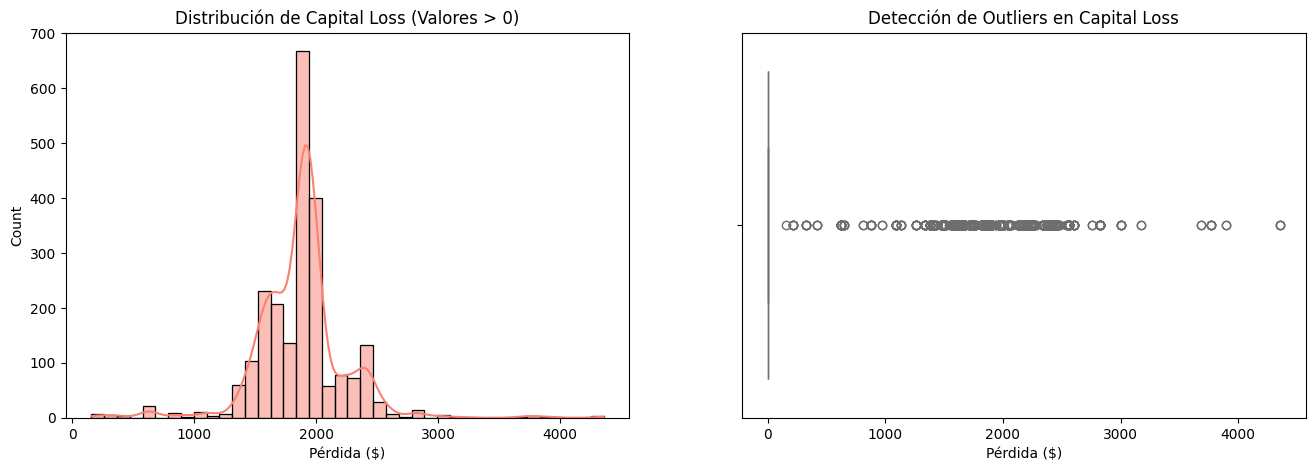

Registros con pérdida = 0: 46560 (95.33%)
Valor máximo de pérdida: 4356


In [10]:
# 1. Filtramos los valores mayores a 0 para el análisis de distribución
loss_nonzero = df_raw[df_raw['capital-loss'] > 0]['capital-loss']

# 2. Creamos las visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de pérdidas (solo valores > 0)
sns.histplot(loss_nonzero, bins=40, kde=True, ax=ax1, color='salmon')
ax1.set_title('Distribución de Capital Loss (Valores > 0)')
ax1.set_xlabel('Pérdida ($)')

# Boxplot para detectar valores extremos
sns.boxplot(x=df_raw['capital-loss'], ax=ax2, color='lightcoral')
ax2.set_title('Detección de Outliers en Capital Loss')
ax2.set_xlabel('Pérdida ($)')

plt.show()

# 3. Estadísticas de interés
total_records = len(df_raw)
zeros_count = len(df_raw[df_raw['capital-loss'] == 0])
print(f"Registros con pérdida = 0: {zeros_count} ({zeros_count/total_records*100:.2f}%)")
print(f"Valor máximo de pérdida: {df_raw['capital-loss'].max()}")

Podemos ver que la distribución se ve mucho mas clara, pero los registros = 0 representan un 95.33% de todos los valores de la variable, por lo cual eliminarlos posiblemente distorsione la variable. Tenemos prácticamente el mismo caso con la variable 'Capital_gain'

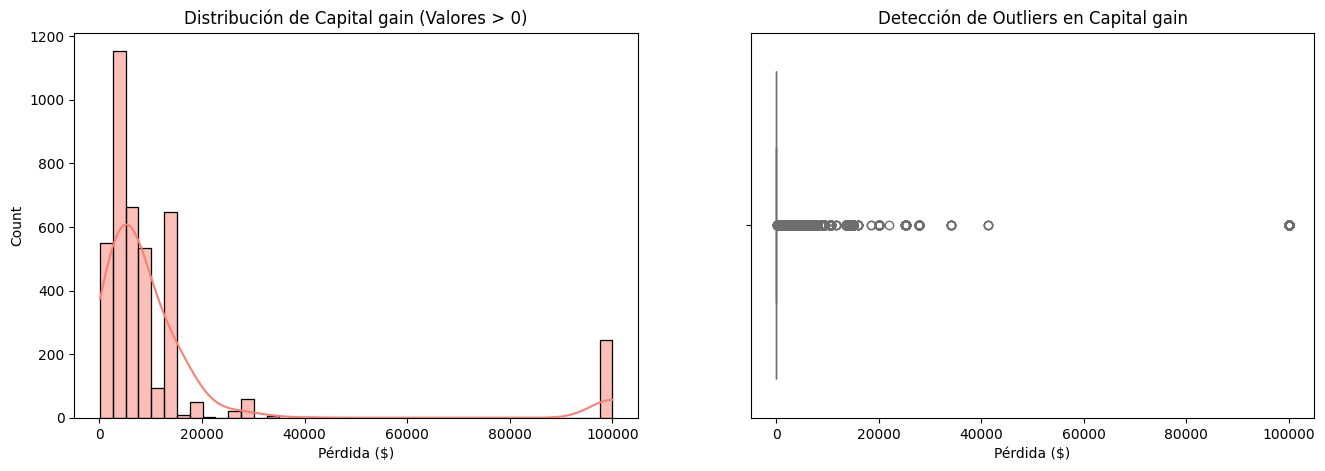

Registros con pérdida = 0: 44807 (91.74%)
Valor máximo de pérdida: 99999


In [11]:
# 1. Filtramos los valores mayores a 0 para el análisis de distribución
loss_nonzero = df_raw[df_raw['capital-gain'] > 0]['capital-gain']

# 2. Creamos las visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de pérdidas (solo valores > 0)
sns.histplot(loss_nonzero, bins=40, kde=True, ax=ax1, color='salmon')
ax1.set_title('Distribución de Capital gain (Valores > 0)')
ax1.set_xlabel('Pérdida ($)')

# Boxplot para detectar valores extremos
sns.boxplot(x=df_raw['capital-gain'], ax=ax2, color='lightcoral')
ax2.set_title('Detección de Outliers en Capital gain')
ax2.set_xlabel('Pérdida ($)')

plt.show()

# 3. Estadísticas de interés
total_records = len(df_raw)
zeros_count = len(df_raw[df_raw['capital-gain'] == 0])
print(f"Registros con pérdida = 0: {zeros_count} ({zeros_count/total_records*100:.2f}%)")
print(f"Valor máximo de pérdida: {df_raw['capital-gain'].max()}")

Vamos a aplicar un Logaritmo a las variables 'Capital-gain' y 'Capital-loss' para ver como cambia su distribución 

NO TIENE SENTIDO TIRAR LOGARITMO A CAPITA-GAIN Y CAPITAL-LOSS. PORQUE AL FINAL LO QUE DISTORSIONA LA DISTIRBUCIÓN ES EL VALOR 0. Y ES NORMAL QUE HAYA 0 GANANCIAS O PÉRDIDAS EN LOS ÚLTIMOS 12 MESES.

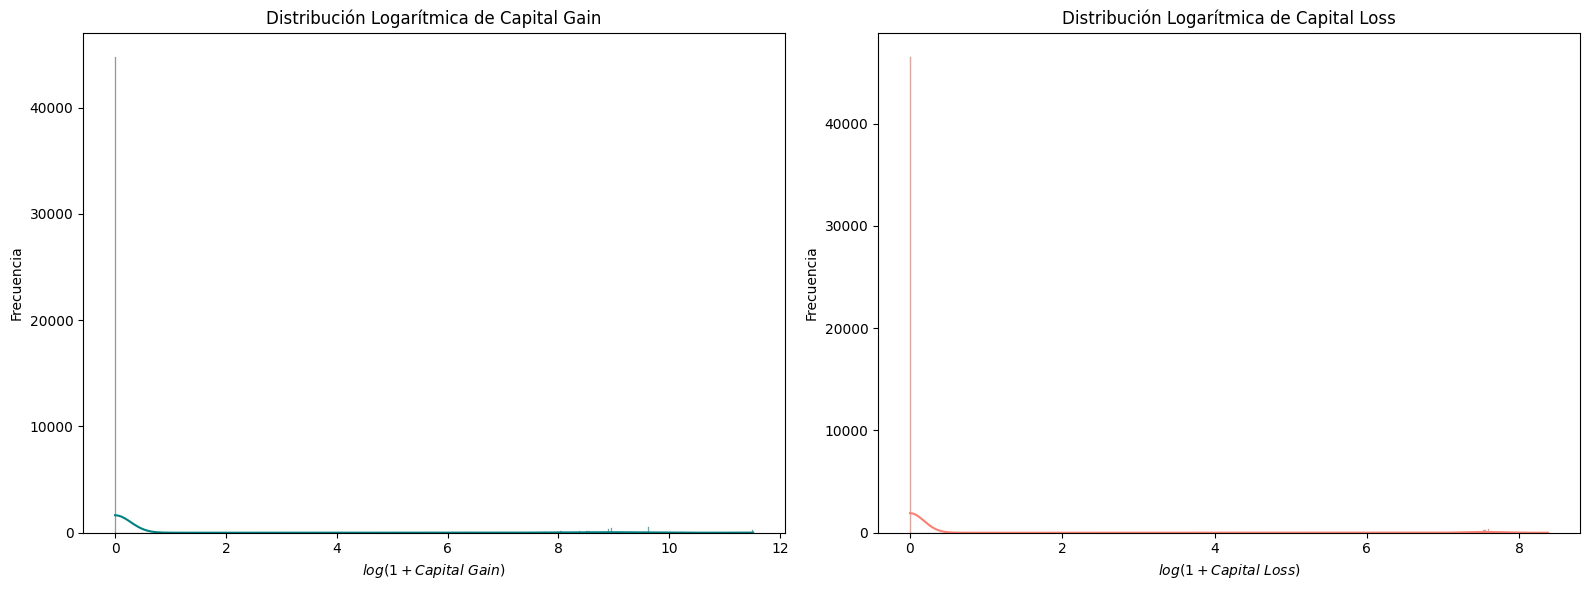

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico para Capital Gain usando log(1+x)
sns.histplot(np.log1p(df_raw['capital-gain']), kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución Logarítmica de Capital Gain')
axes[0].set_xlabel('$log(1 + Capital\ Gain)$')
axes[0].set_ylabel('Frecuencia')

# 2. Gráfico para Capital Loss usando log(1+x)
sns.histplot(np.log1p(df_raw['capital-loss']), kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución Logarítmica de Capital Loss')
axes[1].set_xlabel('$log(1 + Capital\ Loss)$')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

El cambio no es tan siquiera perceptible, más adelante tendremos que pensar como trataremos estas variables.

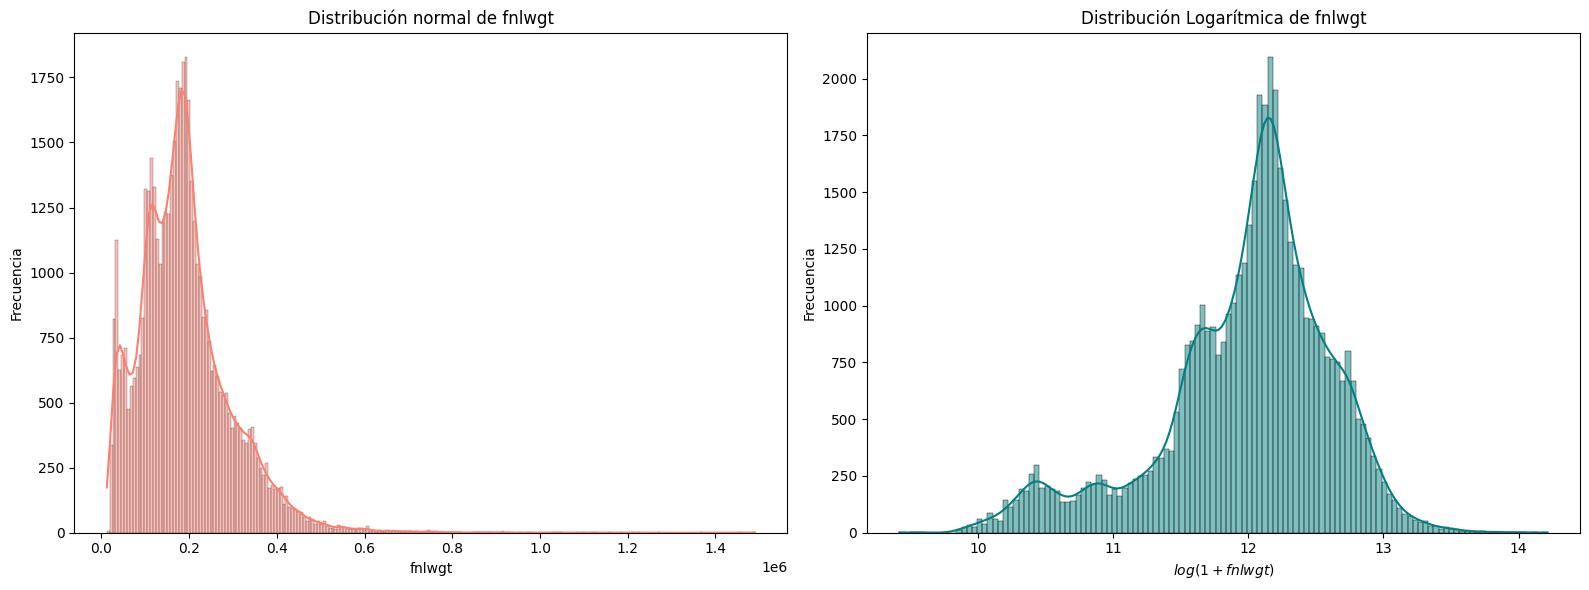

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico origianal 'fnlwgt'
sns.histplot(df_raw['fnlwgt'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribución normal de fnlwgt')
axes[0].set_xlabel('fnlwgt')
axes[0].set_ylabel('Frecuencia')

# 2. Gráfico para 'fnlwgt' usando log(1+x)
sns.histplot(np.log1p(df_raw['fnlwgt']), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribución Logarítmica de fnlwgt')
axes[1].set_xlabel('$log(1 + fnlwgt)$')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Observamos que en la distribución normal presenta skewness y una cúrtosis alta. Por lo que para reducir el impacto de los outliers vamos a intentar reducirlo por un logaritmo. El resultado de la derecha es una distribución logarítima de 'fnlwgt', observamos que hemos tomado la decisión correcta para poder ver la distribución de manera mucho más clara. Por lo que en el preprocessing, vamos a implementar el logaritmo a esta variable.

#### Hours-per-week

Vamos a aplicar una escala logaritmica en 'hours-per-week' para ver si mejora su distribución

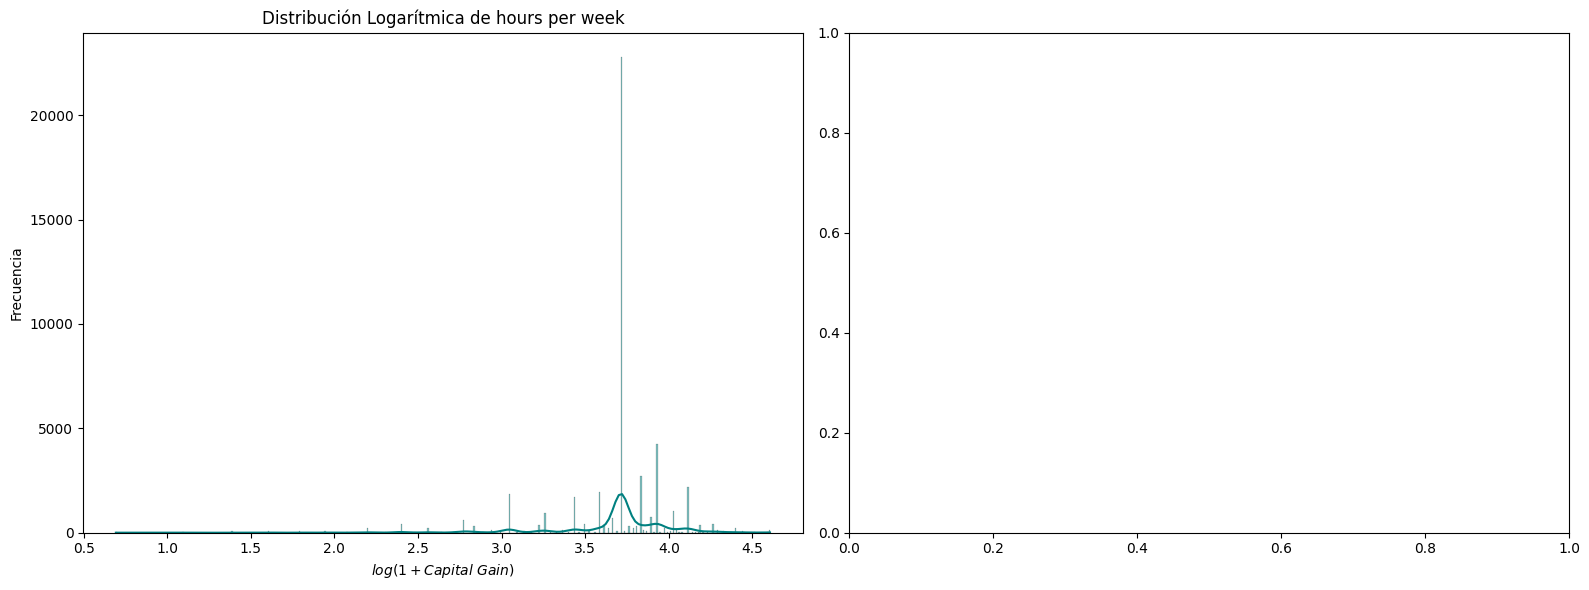

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(np.log1p(df_raw['hours-per-week']), kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución Logarítmica de hours per week')
axes[0].set_xlabel('$log(1 + Capital\ Gain)$')
axes[0].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Filtramos quitando el 1% más bajo y el 1% más alto

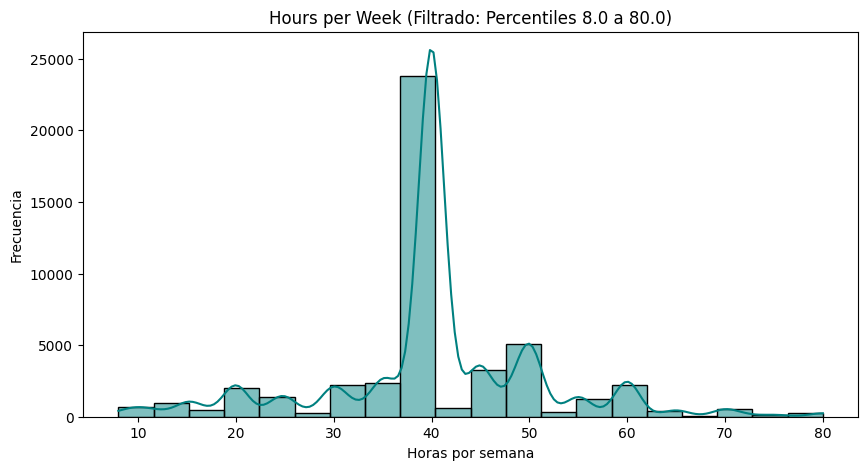

Original: 48842 filas
Filtrado: 48069 filas


In [16]:
# 1. Calculamos los límites (Percentil 1 y Percentil 99)
lower_limit = df_raw['hours-per-week'].quantile(0.01)
upper_limit = df_raw['hours-per-week'].quantile(0.99)

# 2. Filtramos el DataFrame
df_filtered = df_raw[(df_raw['hours-per-week'] >= lower_limit) & (df_raw['hours-per-week'] <= upper_limit)]

# 3. Visualizamos
plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['hours-per-week'], kde=True, color='teal', bins=20)

plt.title(f'Hours per Week (Filtrado: Percentiles {lower_limit} a {upper_limit})')
plt.xlabel('Horas por semana')
plt.ylabel('Frecuencia')
plt.show()

print(f"Original: {len(df_raw)} filas")
print(f"Filtrado: {len(df_filtered)} filas")

Podemos observar que la distribución es considerablemente mas visible.